In [1]:
import cv2
import numpy as np
import platform
import multiprocessing as mpr
import os
import time
from numba import jit, vectorize, int16, njit
import matplotlib.pyplot as plt
# @njit(fastmath=True, cache=True, parallel=True)
from ultralytics import YOLO
import subprocess

In [2]:
calibration_frames = np.load("calibration_frames_1737478984.5221686.npz")
rgb_img = calibration_frames["rgb_image"]
thermal_img = calibration_frames["thermal_img"]

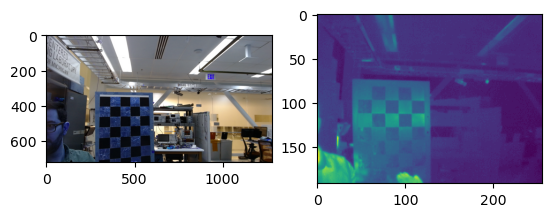

In [3]:
plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(rgb_img)
plt.subplot(1, 2, 2)
plt.imshow(thermal_img)

In [20]:
def resize_with_aspect_ratio(image, target_size):
    h, w = image.shape[:2]
    scale = min(target_size / h, target_size / w)
    new_w, new_h = int(w * scale), int(h * scale)
    resized_image = cv2.resize(image, (new_w, new_h))
    return resized_image


def pad_to_target_size(image, target_size):
    h, w = image.shape[:2]
    pad_h = (target_size - h) // 2
    pad_w = (target_size - w) // 2
    padded_image = cv2.copyMakeBorder(
        image,
        pad_h,
        target_size - h - pad_h,
        pad_w,
        target_size - w - pad_w,
        cv2.BORDER_CONSTANT,
        value=[0, 0, 0],
    )
    return padded_image


def preprocess_images(img1, img2, target_size=500):
    # Convert RGB image to grayscale if necessary
    if len(img2.shape) == 3:
        img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    # Resize images with aspect ratio
    img1_resized = resize_with_aspect_ratio(img1, target_size)
    img2_resized = resize_with_aspect_ratio(img2, target_size)

    # Pad images to the target size
    img1_padded = pad_to_target_size(img1_resized, target_size)
    img2_padded = pad_to_target_size(img2_resized, target_size)

    return img1_padded, img2_padded


def find_keypoints_and_matches(img1, img2):
    # Initialize the ORB detector
    orb = cv2.ORB_create()

    # Detect keypoints and compute descriptors
    kp1, des1 = orb.detectAndCompute(img1, None)
    kp2, des2 = orb.detectAndCompute(img2, None)

    # Initialize the Brute Force Matcher
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

    # Match descriptors
    matches = bf.match(des1, des2)

    # Sort matches by distance (best matches first)
    matches = sorted(matches, key=lambda x: x.distance)

    return kp1, kp2, matches


def draw_matches(img1, kp1, img2, kp2, matches):
    # Draw matches
    img_matches = cv2.drawMatches(
        img1,
        kp1,
        img2,
        kp2,
        matches[:10],
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
    )
    return img_matches


# Example usage
img1 = cv2.cvtColor(rgb_img, cv2.COLOR_BGR2GRAY)
img2 = thermal_img

img1_preprocessed, img2_preprocessed = preprocess_images(img1, img2)
kp1, kp2, matches = find_keypoints_and_matches(img1_preprocessed, img2_preprocessed)
img_matches = draw_matches(img1_preprocessed, kp1, img2_preprocessed, kp2, matches)

# Display the matches
cv2.imshow("Matches", img_matches)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [20]:
import cv2
import numpy as np
import torch
from models.matching import Matching
from models.utils import frame2tensor


def enhance_contrast(image):
    # Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced_image = clahe.apply(image)
    return enhanced_image


def invert_image(image):
    # Invert the image
    inverted_image = 255 - image
    return inverted_image


def preprocess_images(img1, img2, target_size=640):
    # Convert RGB image to grayscale if necessary
    if len(img2.shape) == 3:
        img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

    # Resize images with aspect ratio
    img1_resized = resize_with_aspect_ratio(img1, target_size)
    img2_resized = resize_with_aspect_ratio(img2, target_size)

    return img1_resized, img2_resized


def resize_with_aspect_ratio(image, target_size):
    h, w = image.shape[:2]
    scale = min(target_size / h, target_size / w)
    new_w, new_h = int(w * scale), int(h * scale)
    resized_image = cv2.resize(image, (new_w, new_h))
    return resized_image


def draw_matches(img1, kp1, img2, kp2, matches):
    # Draw matches
    img_matches = cv2.drawMatches(
        img1,
        kp1,
        img2,
        kp2,
        matches[:10],
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
    )
    return img_matches


# Load SuperGlue and SuperPoint models
device = "cuda" if torch.cuda.is_available() else "cpu"
config = {
    "superpoint": {"nms_radius": 4, "keypoint_threshold": 0.005, "max_keypoints": -1},
    "superglue": {
        "weights": "indoor",
        "sinkhorn_iterations": 20,
        "match_threshold": 0.2,
    },
}
matching = Matching(config).eval().to(device)

# Example usage
img1 = cv2.cvtColor(rgb_img, cv2.COLOR_BGR2GRAY)
img2 = invert_image(enhance_contrast(thermal_img))


img1_preprocessed, img2_preprocessed = preprocess_images(img1, img2)

# Convert images to tensors
img1_tensor = frame2tensor(img1_preprocessed, device)
img2_tensor = frame2tensor(img2_preprocessed, device)

# Perform matching
pred = matching({"image0": img1_tensor, "image1": img2_tensor})
matches = pred["matches0"][0].cpu().numpy()
keypoints0 = pred["keypoints0"][0].cpu().numpy()
keypoints1 = pred["keypoints1"][0].cpu().numpy()

# Filter valid matches
valid = matches > -1
mkpts0 = keypoints0[valid]
mkpts1 = keypoints1[matches[valid]]

# Draw matches
img_matches = cv2.drawMatches(
    img1_preprocessed,
    [cv2.KeyPoint(x, y, 1) for x, y in mkpts0],
    img2_preprocessed,
    [cv2.KeyPoint(x, y, 1) for x, y in mkpts1],
    [cv2.DMatch(i, i, 0) for i in range(len(mkpts0))],
    None,
)

# Display the matches
cv2.imshow("Matches", img_matches)
cv2.waitKey(0)
cv2.destroyAllWindows()

Loaded SuperPoint model
Loaded SuperGlue model ("indoor" weights)


In [21]:
def warp_image(img1, img2, mkpts0, mkpts1):
    # Compute homography matrix using RANSAC
    H, mask = cv2.findHomography(mkpts1, mkpts0, cv2.RANSAC, 5.0)

    # Warp img2 to align with img1
    height, width = img1.shape[:2]
    warped_img2 = cv2.warpPerspective(img2, H, (width, height))
    return warped_img2, H

def crop_to_fit(img1, warped_img2):
    # Find the bounding box of the non-zero region in the warped image
    gray = cv2.cvtColor(warped_img2, cv2.COLOR_BGR2GRAY) if len(warped_img2.shape) == 3 else warped_img2
    _, thresh = cv2.threshold(gray, 1, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x, y, w, h = cv2.boundingRect(contours[0])

    # Crop both images to the bounding box
    cropped_img1 = img1[y:y+h, x:x+w]
    cropped_warped_img2 = warped_img2[y:y+h, x:x+w]
    return cropped_img1, cropped_warped_img2

# Example usage
# Assuming img1_preprocessed, img2_preprocessed, mkpts0, and mkpts1 are already defined
warped_img2, H = warp_image(img1_preprocessed, img2_preprocessed, mkpts0, mkpts1)
cropped_img1, cropped_warped_img2 = crop_to_fit(img1_preprocessed, warped_img2)

# Display the before and after of img2 and the cropped img1
cv2.imshow('Original Image 2', img2_preprocessed)
cv2.imshow('Warped Image 2', warped_img2)
cv2.imshow('Cropped Image 1', cropped_img1)
cv2.imshow('Cropped Warped Image 2', cropped_warped_img2)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [32]:
np.savez_compressed("bad_keypoints.npz", mkpts0=mkpts0, mkpts1=mkpts1)

In [15]:
cropped_warped_img2_mask = threshold_thermal(cropped_warped_img2, 80,120)
result = np.bitwise_and(cropped_warped_img2_mask, cropped_img1)
cv2.imshow("Result", cropped_warped_img2_mask)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [13]:
def threshold_thermal(thermal_img, lower_threshold, upper_threshold):
    # print(np.mean(thermal_img), np.std(thermal_img))
    thermal_mask = np.where(
        (thermal_img >= lower_threshold) & (thermal_img <= upper_threshold), 0, 255
    ).astype(np.uint8)

    kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT, (5, 5)
    )  # Adjust size based on your blobs

    thermal_mask = cv2.erode(thermal_mask, kernel, iterations=4)
    thermal_mask = cv2.dilate(thermal_mask, kernel, iterations=1)

    return thermal_mask
